In [9]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [10]:
input_shape = (28, 28, 1)
num_classes = 10

In [12]:
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
np.max(y_train)

np.uint8(9)

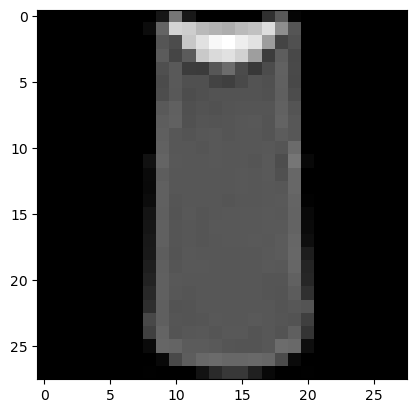

In [14]:
plt.imshow(x_train[2], 'gray')
plt.show()

In [15]:
def myModel(input_shape, num_classes):    
    inputs = layers.Input(shape=input_shape)
    net = layers.Conv2D(32, 3, 1, padding='same', activation='relu')(inputs)
    #net = layers.Conv2D(32, 3, 1, padding='same', activation='relu')(net)
    net = layers.MaxPool2D((2, 2))(net)
    
    net = layers.Conv2D(64, 3, 1, padding='same', activation='relu')(net)
    #net = layers.Conv2D(64, 3, 1, padding='same', activation='relu')(net)
    net = layers.MaxPool2D((2, 2))(net)
    
    net = layers.Flatten()(net)
    net = layers.Dense(512, activation='relu')(net)
    net = layers.Dense(num_classes, activation='softmax')(net)
    
    model = tf.keras.Model(inputs=inputs, outputs=net, name = 'TestModel') # 요거 이름 공란 있으면 밑에서 오류남 

    return model

In [16]:
model = myModel(input_shape, num_classes)

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy', 
              metrics=['accuracy'])

In [19]:
x_train_4d = x_train[..., tf.newaxis] # 3D -> 4D
print(x_train_4d.shape, x_train.shape, x_train_4d.dtype)
x_train_4d = x_train_4d / 255.0 # scaling to [0,1]
print(np.max(x_train_4d), np.min(x_train_4d))

(60000, 28, 28, 1) (60000, 28, 28) uint8
1.0 0.0


In [21]:
x_test_4d = x_test[..., tf.newaxis] # 3D -> 4D
x_test_4d = x_test_4d / 255.0
print(x_test_4d.shape)

(10000, 28, 28, 1)


In [22]:
num_epochs = 10
bs = 32
hist = model.fit(x_train_4d, y_train, validation_data = (x_test_4d, y_test), batch_size=bs, shuffle=True, epochs=num_epochs)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8616 - loss: 0.3809 - val_accuracy: 0.8952 - val_loss: 0.2921
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9093 - loss: 0.2457 - val_accuracy: 0.9056 - val_loss: 0.2574
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9267 - loss: 0.2004 - val_accuracy: 0.9170 - val_loss: 0.2257
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9386 - loss: 0.1666 - val_accuracy: 0.9097 - val_loss: 0.2494
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9482 - loss: 0.1371 - val_accuracy: 0.9205 - val_loss: 0.2330
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9588 - loss: 0.1087 - val_accuracy: 0.9236 - val_loss: 0.2434
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9678 - loss: 0.0861 - val_accuracy: 0.9125 - val_loss: 0.3025
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9742 - lo

In [23]:
x_test[0:5].shape

(5, 28, 28)

In [24]:
pred = model.predict(x_test_4d[0:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [25]:
type(pred), pred.shape

(numpy.ndarray, (5, 10))

In [26]:
pred

array([[3.6753385e-11, 1.3492722e-09, 4.3189946e-10, 7.7851607e-11,
        4.7891580e-11, 1.1113956e-09, 1.1497143e-10, 2.0784942e-07,
        7.2667199e-11, 9.9999976e-01],
       [1.2985765e-07, 5.0252948e-20, 9.9999988e-01, 1.7861115e-13,
        2.9030930e-15, 8.4578903e-18, 3.7631985e-12, 1.2720085e-14,
        1.9889183e-16, 2.6918817e-18],
       [1.6838447e-16, 1.0000000e+00, 3.7994530e-17, 7.5792693e-16,
        2.3892372e-18, 9.8826976e-25, 5.0356791e-19, 7.5063910e-30,
        1.0933196e-22, 4.8546367e-28],
       [1.2139837e-18, 1.0000000e+00, 2.5646315e-22, 7.6678572e-22,
        1.6296793e-17, 1.3374535e-31, 5.0662531e-21, 5.6317854e-33,
        5.5744111e-28, 4.5472128e-31],
       [1.0031079e-01, 4.2949200e-13, 2.0402392e-04, 8.5897645e-09,
        1.1305939e-05, 8.4238277e-10, 8.9947373e-01, 3.2913174e-08,
        8.1277166e-11, 9.0079418e-08]], dtype=float32)

In [29]:
y_test[0:5], np.argmax(pred, axis=1)

(array([9, 2, 1, 1, 6], dtype=uint8), array([9, 2, 1, 1, 6]))

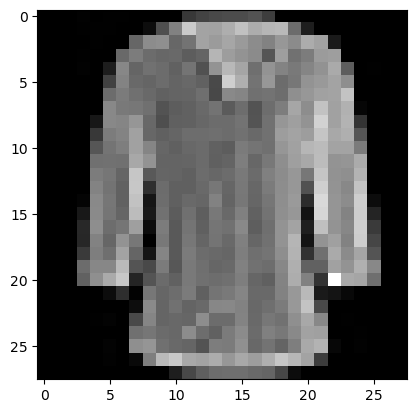

In [31]:
plt.imshow(x_test_4d[4].reshape(28, 28), 'gray')
plt.show()

In [32]:
pred = model.predict(x_test_4d)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [33]:
pred.shape

(10000, 10)

In [34]:
result = np.argmax(pred, axis=1)

In [35]:
result.shape

(10000,)

In [36]:
result, y_test

(array([9, 2, 1, ..., 8, 1, 5], shape=(10000,)),
 array([9, 2, 1, ..., 8, 1, 5], shape=(10000,), dtype=uint8))

In [39]:
cmp = (result == y_test)

In [40]:
cmp

array([ True,  True,  True, ...,  True,  True,  True], shape=(10000,))

In [41]:
cnt = np.sum(cmp)

In [42]:
print(cnt, cnt/y_test.shape[0])

9238 0.9238


In [43]:
falseArray = []
for index, value in enumerate(cmp):
    if value==False:
        falseArray.append(index)

In [44]:
len(falseArray)

762

In [45]:
falseArray

[23,
 25,
 40,
 42,
 48,
 67,
 68,
 73,
 74,
 98,
 147,
 150,
 151,
 153,
 217,
 227,
 239,
 244,
 266,
 271,
 316,
 324,
 325,
 352,
 374,
 378,
 381,
 382,
 389,
 394,
 396,
 404,
 441,
 444,
 460,
 474,
 491,
 498,
 510,
 529,
 536,
 563,
 628,
 629,
 635,
 639,
 655,
 661,
 669,
 670,
 674,
 711,
 716,
 724,
 732,
 736,
 753,
 758,
 760,
 787,
 799,
 851,
 877,
 881,
 893,
 902,
 905,
 909,
 910,
 921,
 930,
 935,
 937,
 939,
 960,
 965,
 977,
 979,
 997,
 1000,
 1005,
 1025,
 1028,
 1055,
 1104,
 1111,
 1129,
 1131,
 1139,
 1142,
 1147,
 1160,
 1165,
 1191,
 1197,
 1210,
 1223,
 1231,
 1234,
 1254,
 1280,
 1300,
 1305,
 1329,
 1336,
 1353,
 1356,
 1376,
 1385,
 1387,
 1396,
 1408,
 1425,
 1449,
 1452,
 1469,
 1482,
 1509,
 1527,
 1528,
 1533,
 1572,
 1617,
 1620,
 1625,
 1640,
 1643,
 1645,
 1650,
 1661,
 1682,
 1710,
 1731,
 1743,
 1744,
 1753,
 1810,
 1822,
 1836,
 1846,
 1878,
 1922,
 1942,
 1943,
 1945,
 1953,
 1964,
 1968,
 2001,
 2006,
 2022,
 2037,
 2048,
 2057,
 2063,
 206

In [54]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [58]:
type(class_names[0])

str

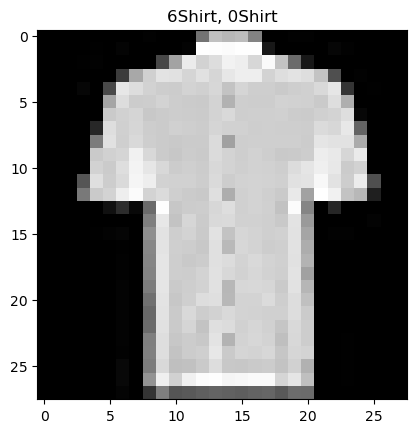

In [62]:
index = 2
plt.imshow(x_test[falseArray[index]].reshape(28, 28), 'gray')
plt.title(str(y_test[falseArray[index]]) + class_names[y_test[falseArray[index]]] +
          ", " + str(result[falseArray[index]]) + class_names[y_test[falseArray[index]]])
plt.show()